In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
import numpy as np
import import_ipynb
from scipy.stats import kruskal
import functions.missing_labs as ml
import functions.eda_model as em

# 1. Data Pre-processing

# 2. Data Imputation

# 3. Explortary Data Analysis - Distributions & Correlation Analysis

In [3]:
# load cleaned dataset
df = ml.load_data("cleaned_dataset_all_vars.csv")

Loaded dataset with shape: (1611, 13)


# 4. Explortary Data Analysis

## 4.1 We standardized the 'PerformedDate' by converting it to a 'VisitOrder' variable—grouping by patient and ordering their lab test records chronologically.

In [4]:
df = df.sort_values(['Patient_ID', 'PerformedDate'])
df['VisitOrder'] = df.groupby('Patient_ID').cumcount() + 1

### 4.2 We observe that most individuals have up to 25 visits. Therefore, by focusing on data from the first 25 visits, we can gain more insight into the characteristics of their lab test results.

/Users/ervinwu/Documents/CHL8010/CPCSSN-Group-Project/functions/eda_model.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[date] = pd.to_datetime(data[date])


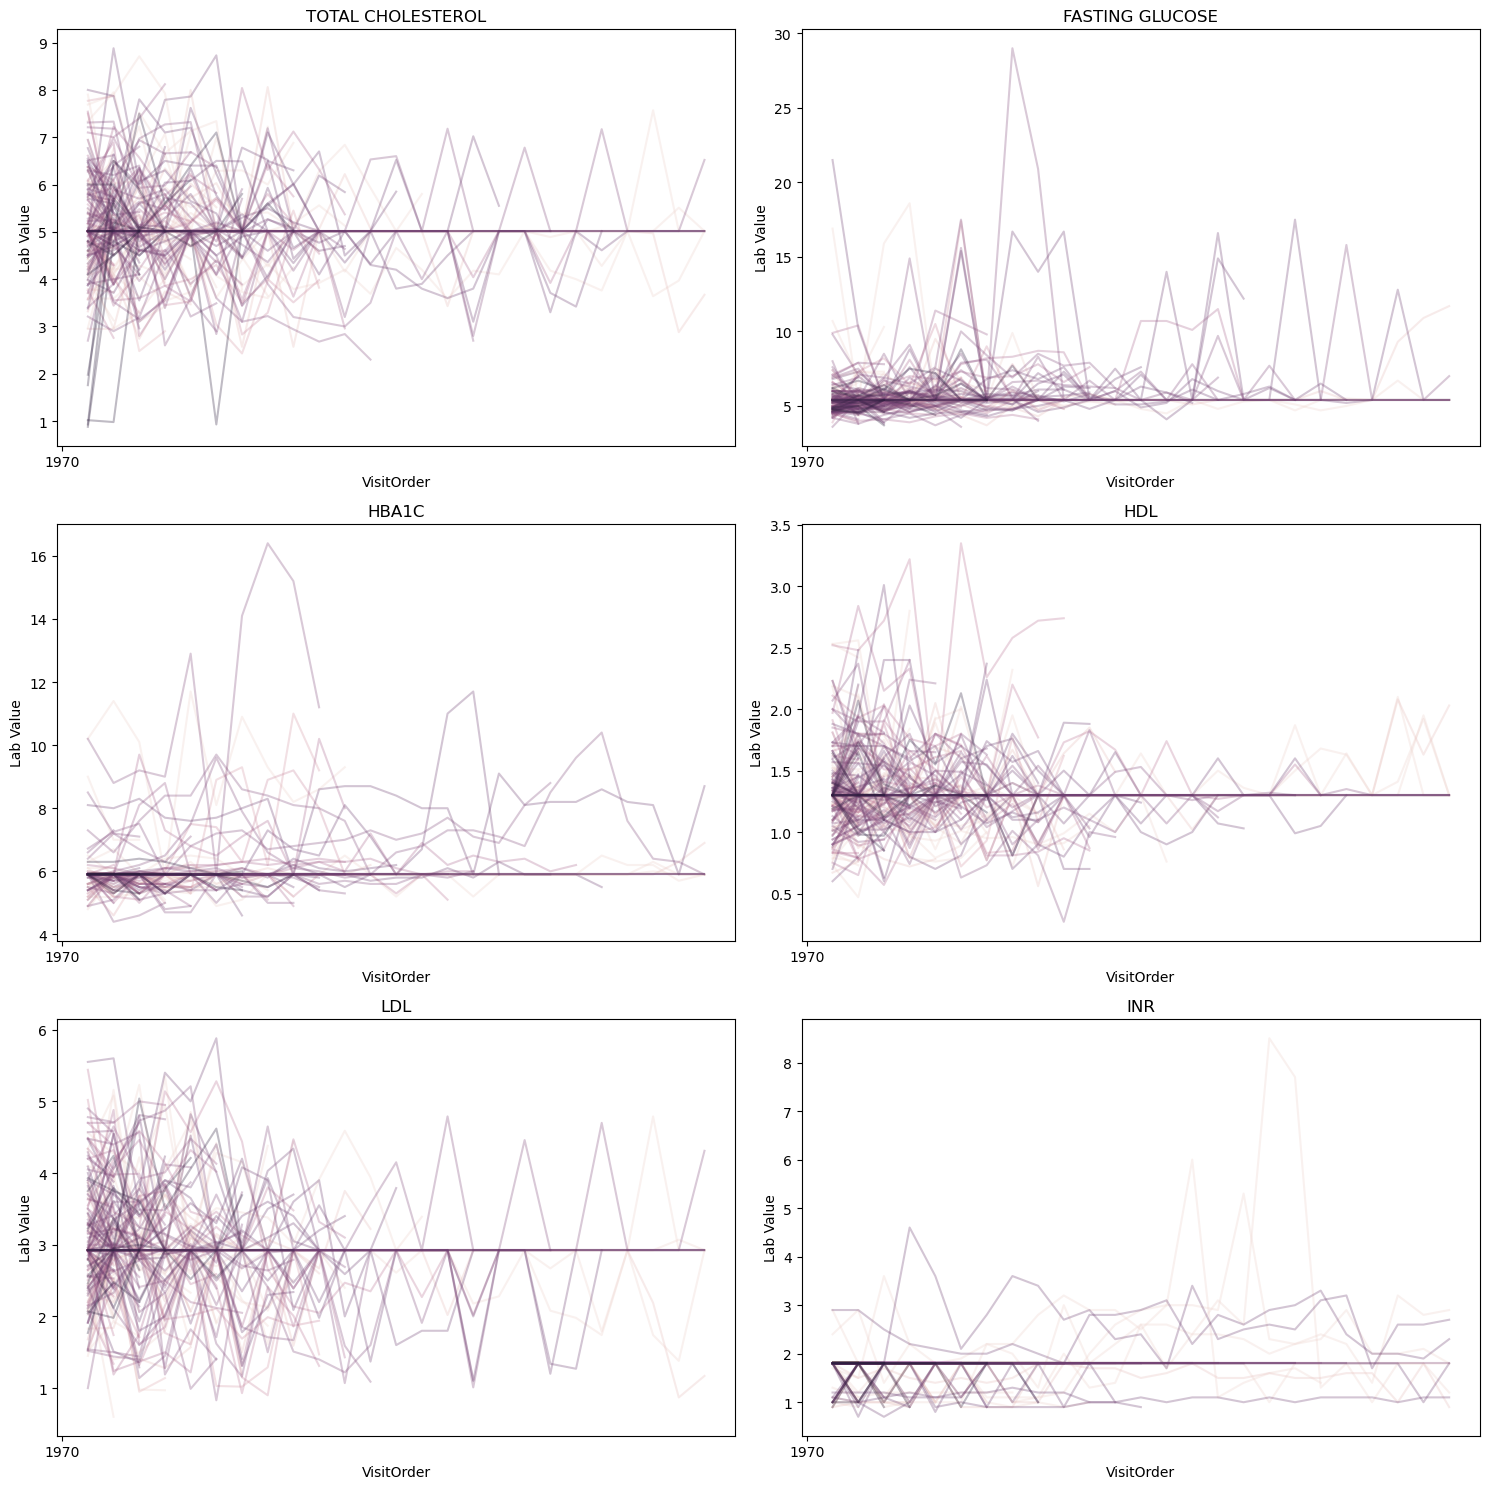

In [6]:
df_25 = df[df['VisitOrder'] <= 25]
em.plot_trends(
    data=df_25,
    variables=['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 
            'HDL', 'LDL', 'INR'],
    date='VisitOrder',
    hue='Patient_ID',
    xlabel='VisitOrder',
    ylabel='Lab Value'
)

## 4.3 visualize subtypes of bipolar disorder

### 4.3.1 mapping & encode subtypes of bipolar disorders

In [7]:
bipolar_map = {
    '296.0': 'BipolarI_SingleManic',
    '296.1': 'BipolarI_RecurrentManic',
    '296.4': 'BipolarI_CurrentManic',
    '296.5': 'BipolarI_CurrentDepressed',
    '296.6': 'BipolarI_CurrentMixed',
    '296.7': 'BipolarI_Unspecified',
    '296.8': 'Bipolar_Unspecified'
}

bipolar_order = [
    'BipolarI_SingleManic',
    'BipolarI_RecurrentManic',
    'BipolarI_CurrentManic',
    'BipolarI_CurrentDepressed',
    'BipolarI_CurrentMixed',
    'BipolarI_Unspecified',
    'Bipolar_Unspecified'
]

df = em.map_encode(
    data=df,
    code='DiagnosisCode_calc',
    mapping_dict=bipolar_map,
    ordered_levels=bipolar_order,
    new_label='Bipolar Disorder Type',
    new_factor='Bipolar Disorder Type Factor',
    new_num='Bipolar Disorder Type Num'
)

### 4.3.2 visualize grouped trajctory of subtypes of bipolar disorders

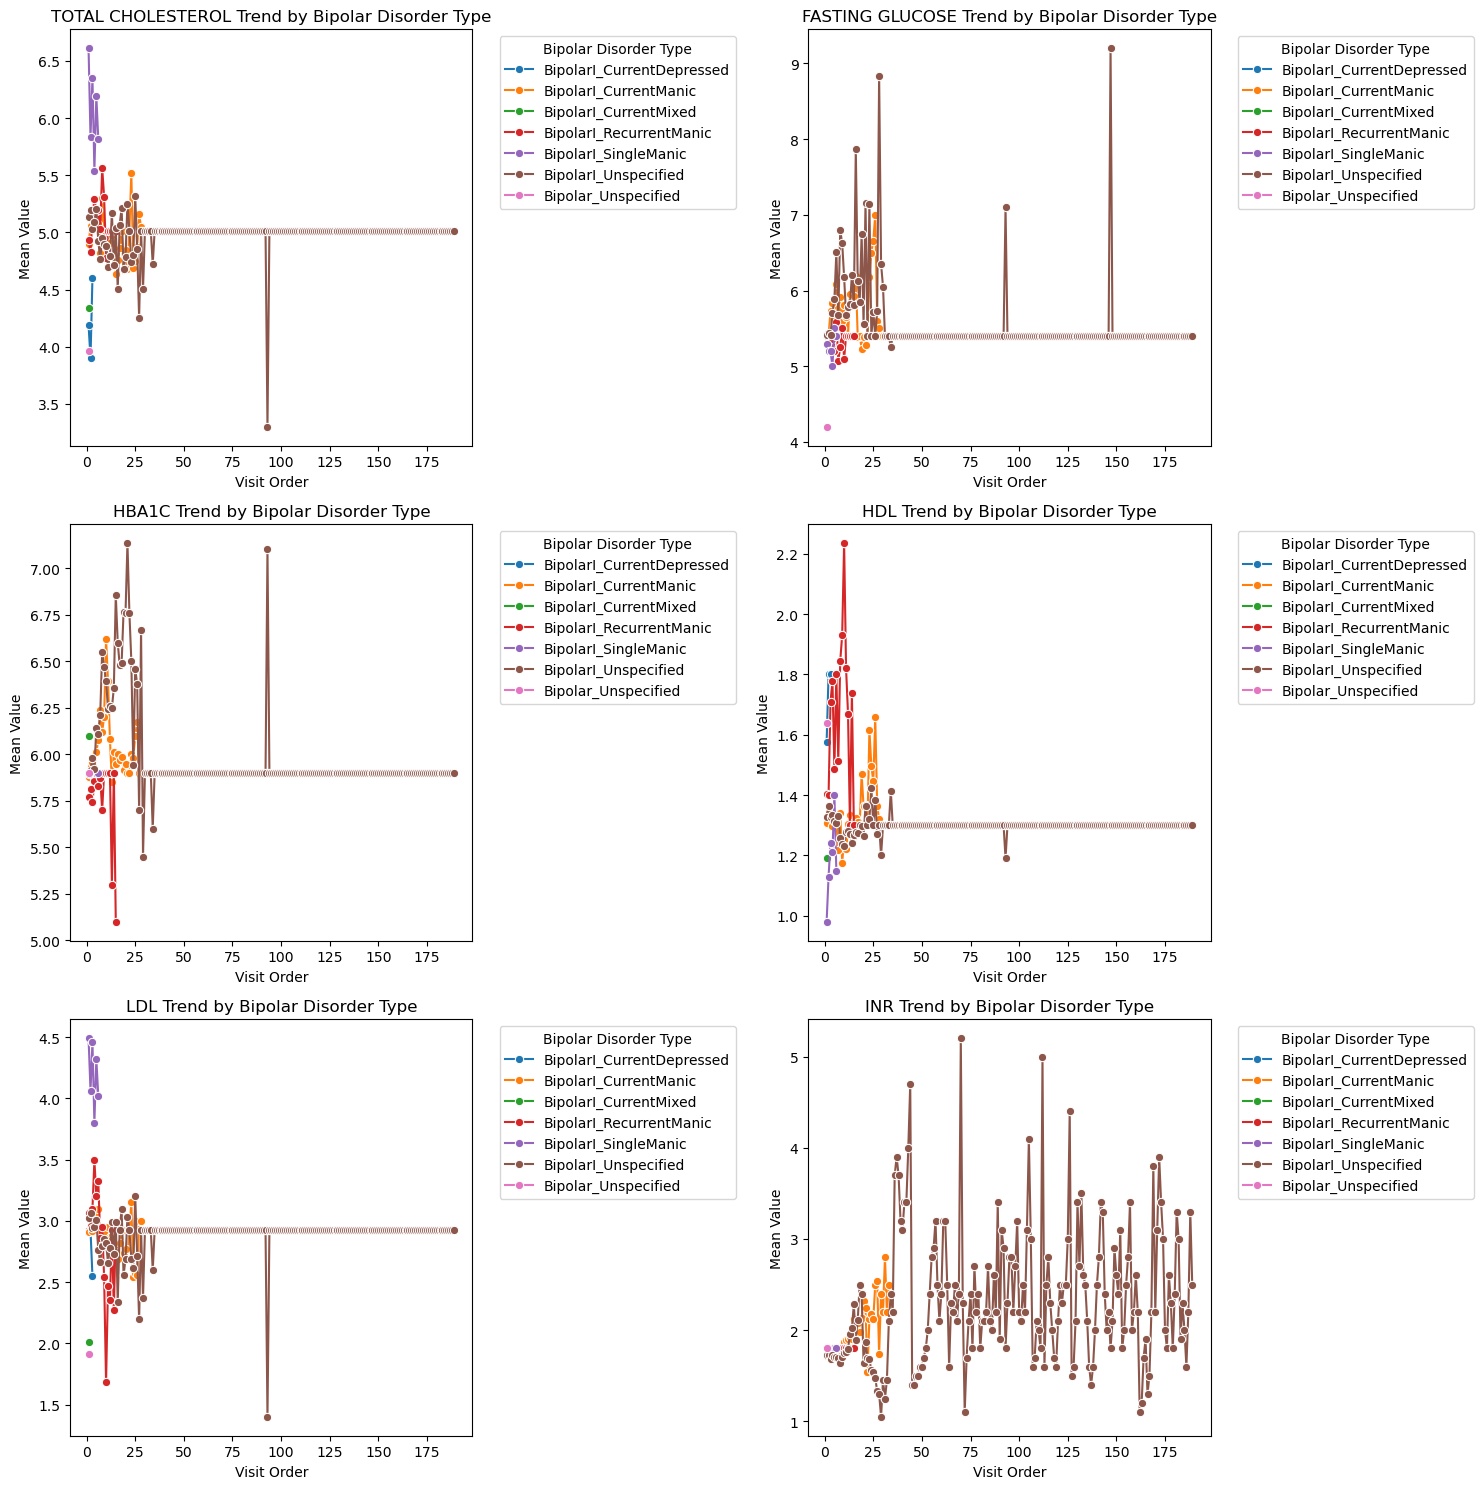

In [8]:
em.plot_grouped_trends(
    data=df,
    variables=['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 
            'HDL', 'LDL', 'INR'],
    group_x='VisitOrder',
    group_hue='Bipolar Disorder Type',
    xlabel='Visit Order',
    ylabel='Mean Value',
    title_prefix='',
)

In [ ]:
em.plot_grouped_boxplots(df, 
                      variables = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
                      group='Bipolar Disorder Type Factor')

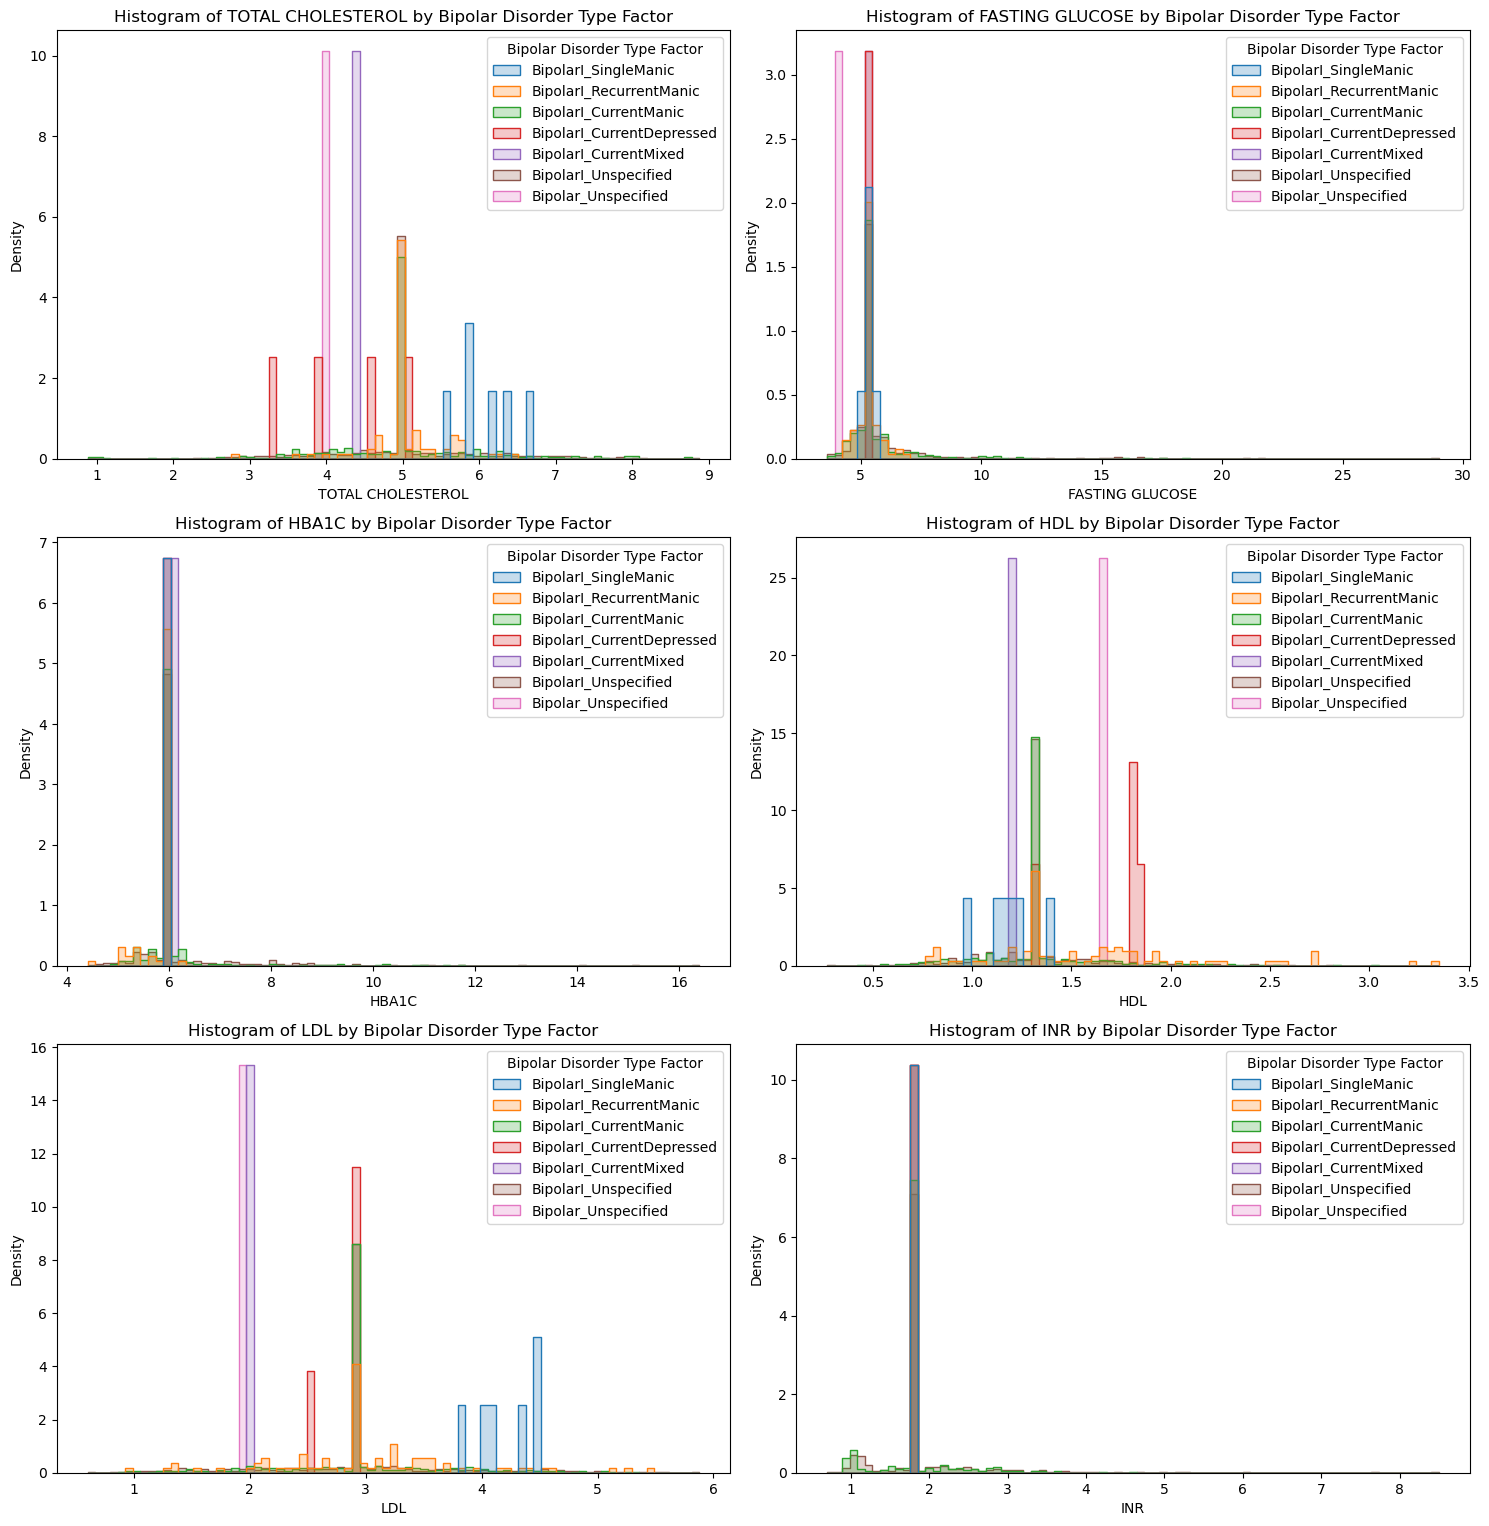

In [9]:
em.plot_grouped_histograms(df, 
                      variables = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
                      group='Bipolar Disorder Type Factor')

## 4.4 visualize states of bipolar disorder

### 4.4.1 mapping & encode states of bipolar disorders

In [10]:
state_map = {
    '296.0': 'Manic',         # BipolarI_SingleManic
    '296.1': 'Manic',         # BipolarI_RecurrentManic
    '296.4': 'Manic',         # BipolarI_CurrentManic
    '296.5': 'Depressed',     # BipolarI_CurrentDepressed
    '296.6': 'Manic',         # BipolarI_CurrentMixed (assigned to Manic, can adjust if needed)
    '296.7': 'Unspecified',   # BipolarI_Unspecified
    '296.8': 'Unspecified'    # Bipolar_Unspecified
}

state_order = ['Manic', 'Depressed', 'Unspecified']

df = em.map_encode(
    data=df,
    code='DiagnosisCode_calc',
    mapping_dict=state_map,
    ordered_levels=state_order,
    new_label='State Type',
    new_factor='State Type Factor',
    new_num='State Type Num'
)

<string>:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
<string>:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
<string>:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
<string>:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
<str

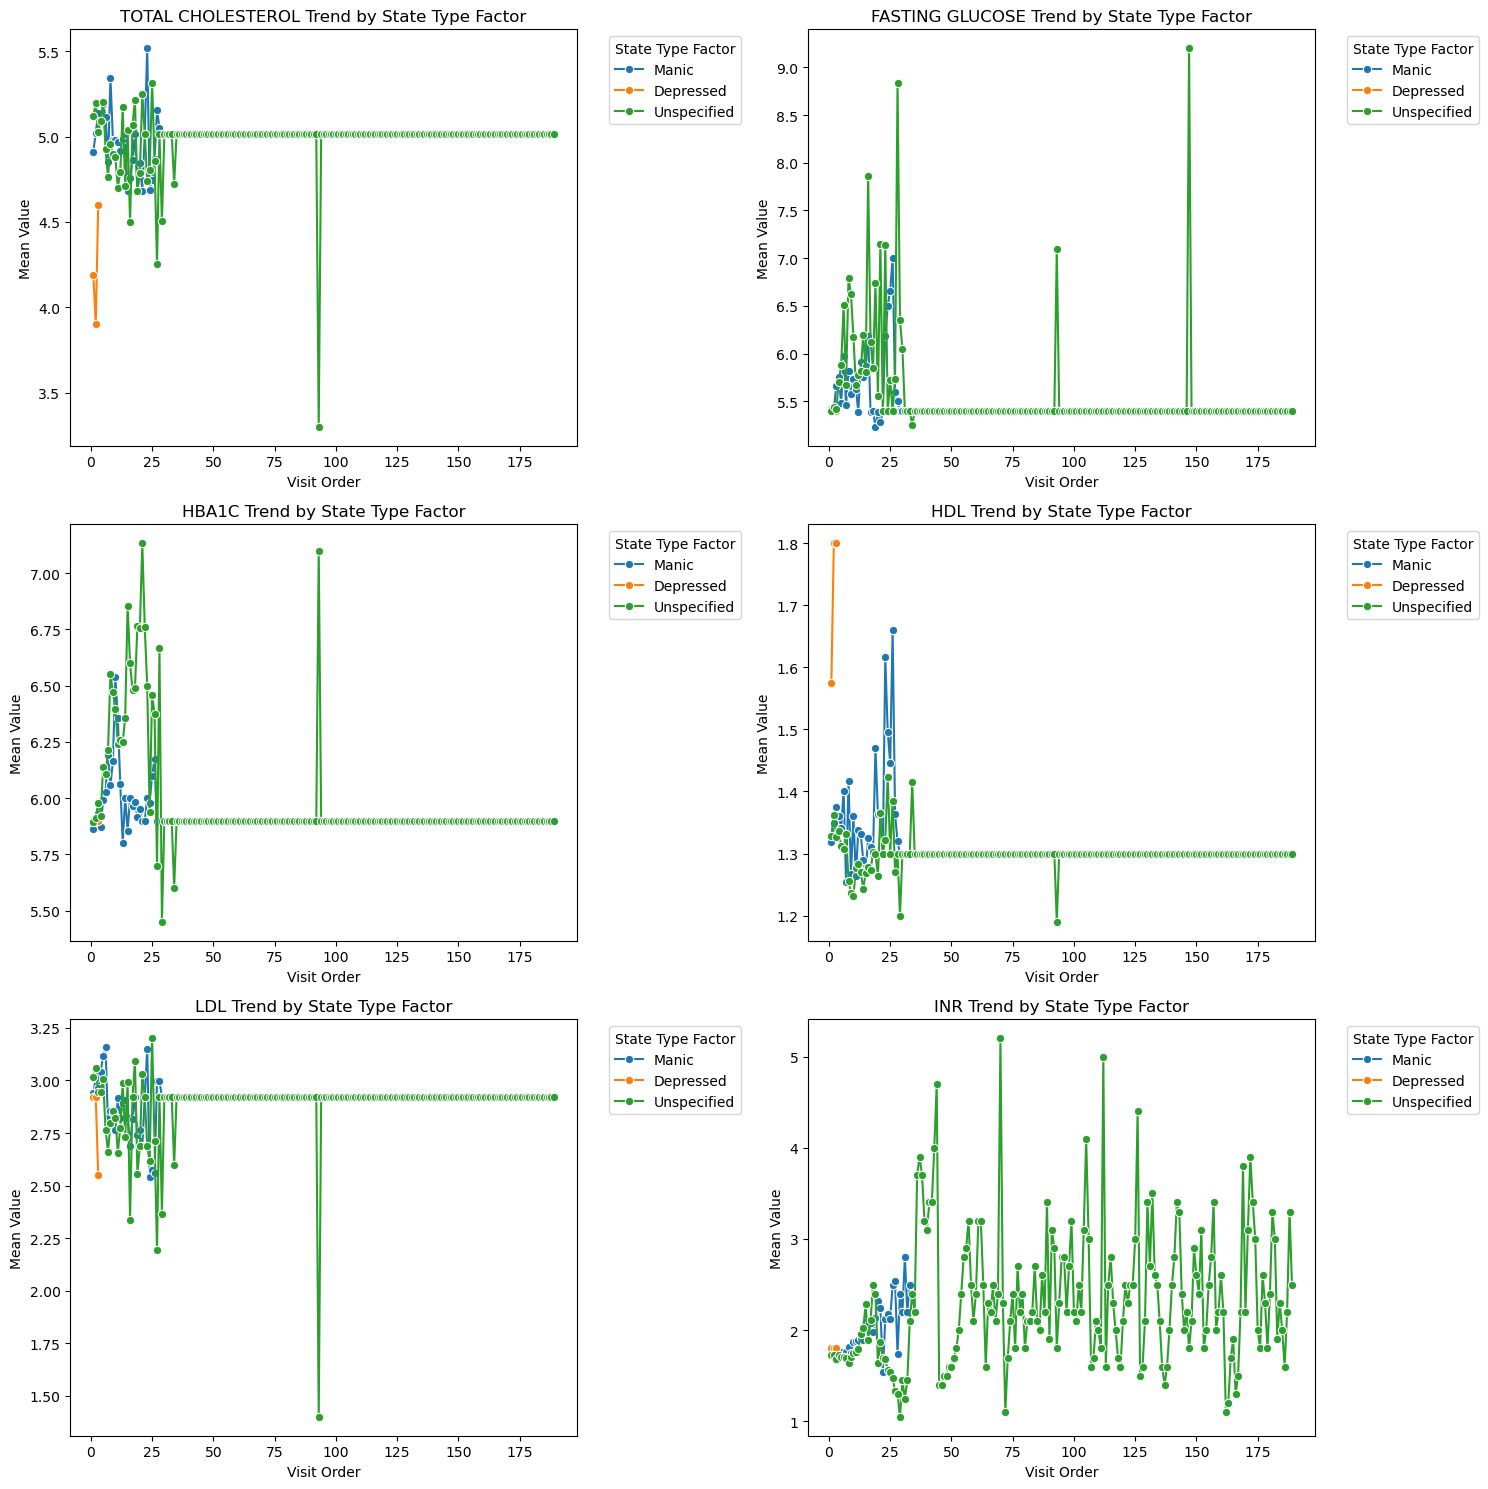

In [11]:
em.plot_grouped_trends(
    data=df,
    variables=['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 
            'HDL', 'LDL', 'INR'],
    group_x='VisitOrder',
    group_hue='State Type Factor',
    xlabel='Visit Order',
    ylabel='Mean Value',
    title_prefix='',
)

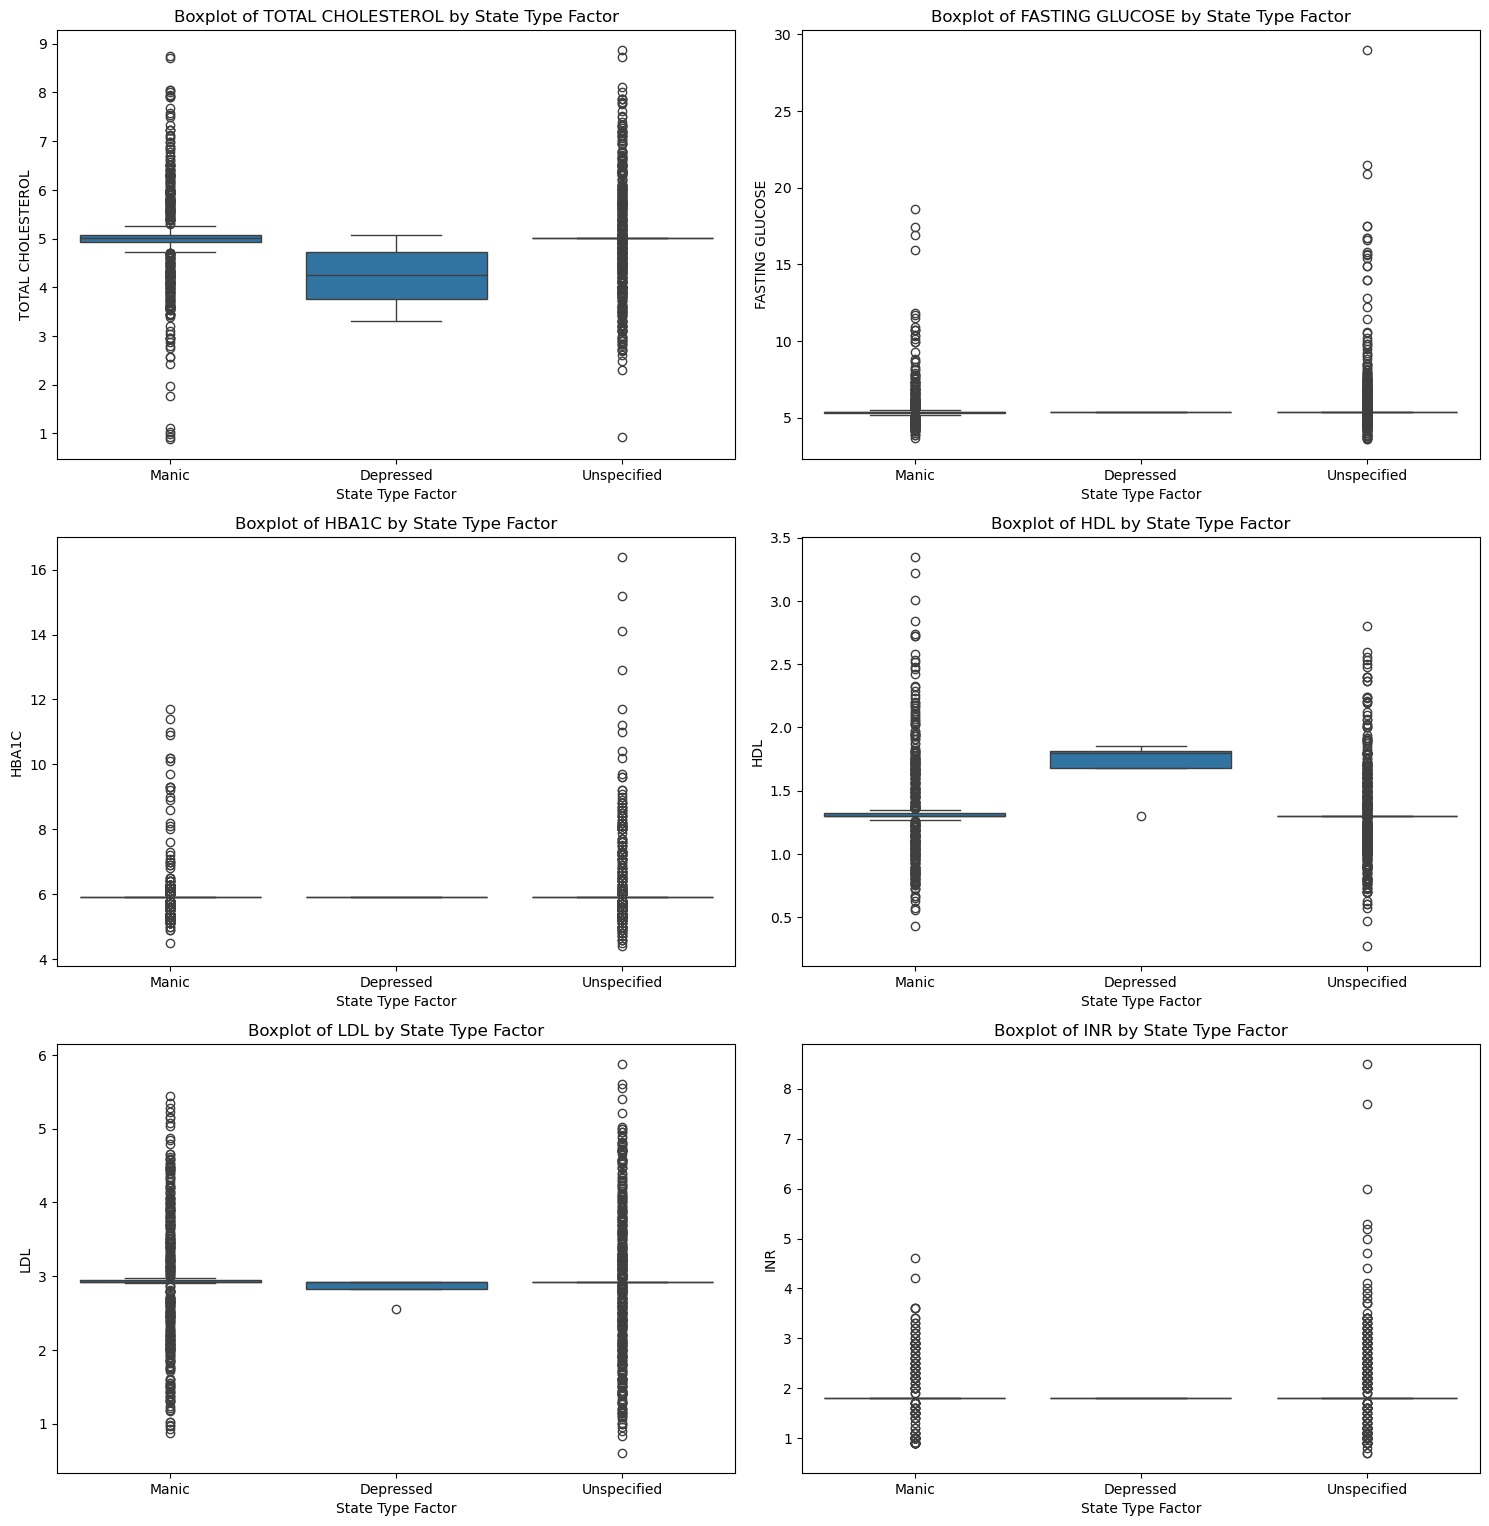

In [12]:
em.plot_grouped_boxplots(df, 
                      variables = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
                      group='State Type Factor')

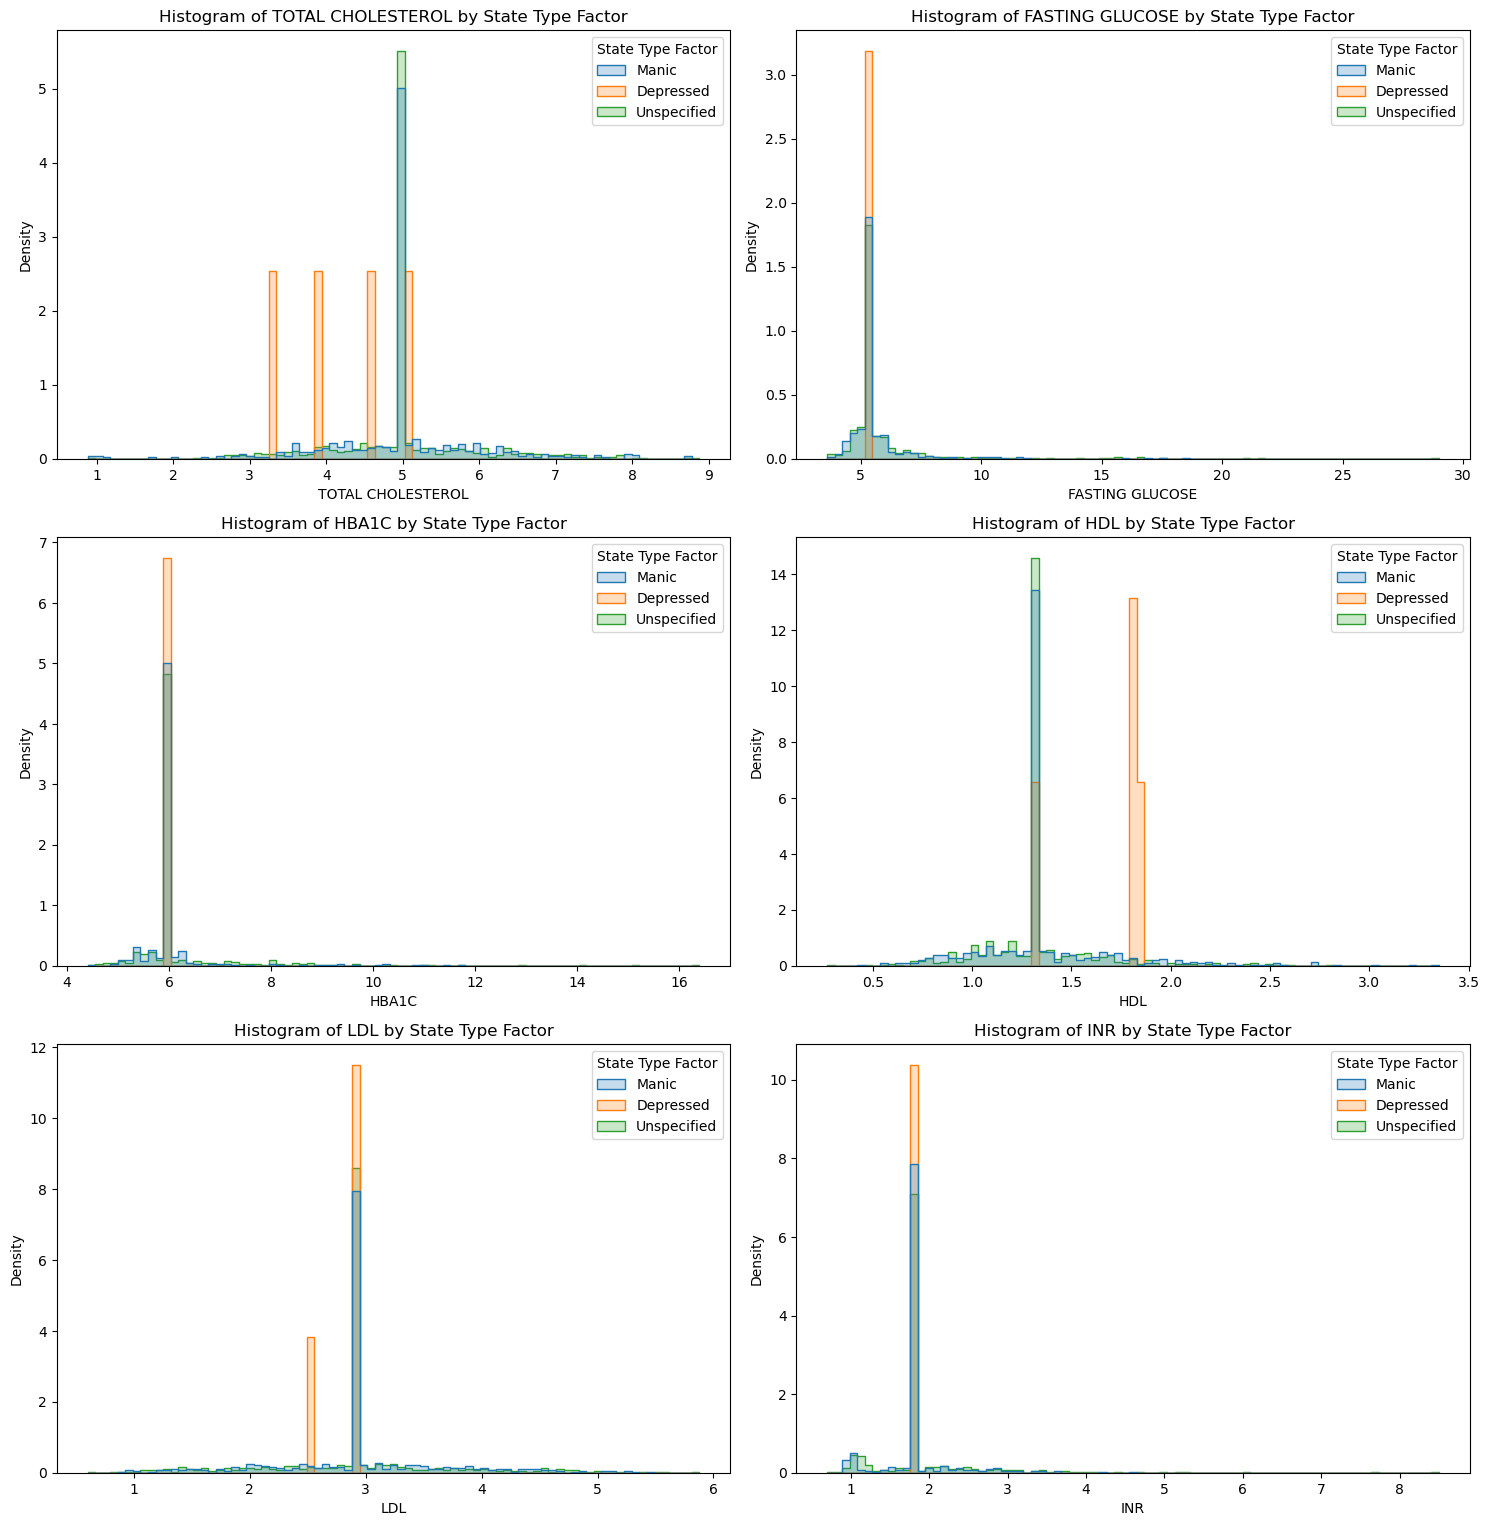

In [13]:
em.plot_grouped_histograms(df, 
                      variables = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
                      group='State Type Factor')

# 5. Modelling

## 5.1 Kruskal-Wallis Test to see whether there are significant differences in the variable across multiple State_factor groups.

In [14]:
from wrangling import kruskal_test
kruskal_test(df, 
             variables= ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
             group_col='Bipolar Disorder Type Factor')


TOTAL CHOLESTEROL: H=18.041, p=0.0012
FASTING GLUCOSE: H=3.992, p=0.2623
HBA1C: H=7.748, p=0.0208
HDL: H=41.204, p=0.0000
LDL: H=21.505, p=0.0003
INR: H=1.302, p=0.2539


<string>:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,variable,n_groups,H_stat,p_value
0,TOTAL CHOLESTEROL,5,18.040769,1.211661e-03
1,FASTING GLUCOSE,4,3.992393,2.622868e-01
2,HBA1C,3,7.748107,2.077400e-02
3,HDL,5,41.204346,2.438301e-08
4,LDL,5,21.505389,2.513631e-04
5,INR,2,1.301704,2.539023e-01


In [15]:
kruskal_test(df, 
             variables= ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
             group_col='State Type Factor')

TOTAL CHOLESTEROL: H=3.043, p=0.2184
FASTING GLUCOSE: H=1.820, p=0.1773
HBA1C: H=1.371, p=0.2417
HDL: H=7.390, p=0.0248
LDL: H=1.751, p=0.4168
INR: H=1.194, p=0.2746


<string>:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,variable,n_groups,H_stat,p_value
0,TOTAL CHOLESTEROL,3,3.043159,0.218367
1,FASTING GLUCOSE,2,1.820028,0.177310
2,HBA1C,2,1.370632,0.241703
3,HDL,3,7.390497,0.024841
4,LDL,3,1.750528,0.416752
5,INR,2,1.193866,0.274551


## 5.2 Random Forest

Best Parameters from GridSearchCV:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Precision (macro): 0.761

 Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       188
           1       0.86      0.95      0.90       188
           2       0.71      0.65      0.68       189
           5       0.69      0.68      0.68       188

    accuracy                           0.82       753
   macro avg       0.81      0.82      0.81       753
weighted avg       0.81      0.82      0.81       753

Confusion Matrix (Raw Counts):

[[187   0   0   1]
 [  0 178   5   5]
 [  1  14 123  51]
 [  1  14  46 127]]


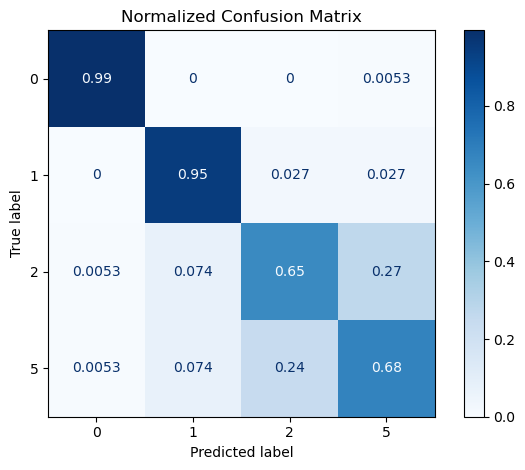

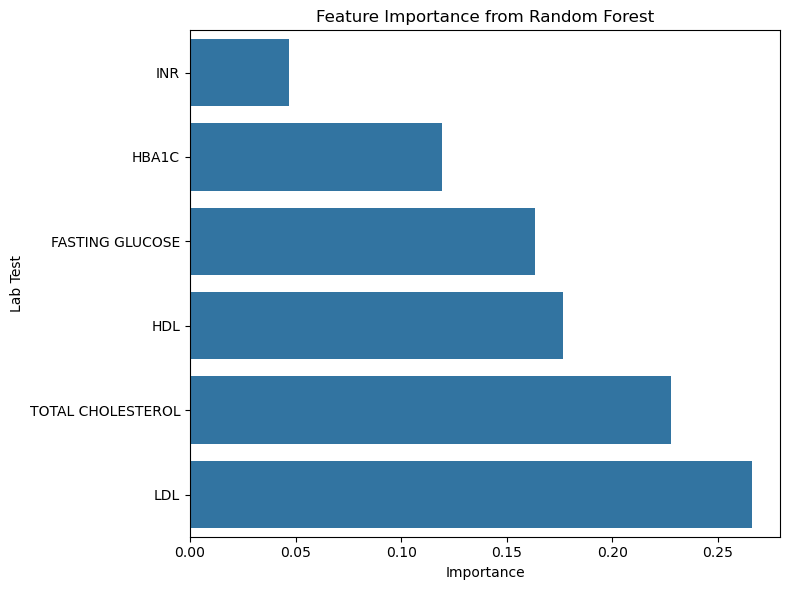


 Cross-Validated Precision (macro): 0.737 ± 0.032


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

# ---------------------------
# Step 1: Data Preprocessing
# ---------------------------
lab_vars = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR']

df_clean = df.dropna(subset=lab_vars + ['Bipolar Disorder Type Factor'])

# Encode target as numeric codes
df_clean['Bipolar Disorder Type Factor'] = pd.Categorical(df_clean['Bipolar Disorder Type Factor']).codes

# Filter out classes with < 5 samples
class_counts = df_clean['Bipolar Disorder Type Factor'].value_counts()
valid_classes = class_counts[class_counts >= 5].index.tolist()
df_filtered = df_clean[df_clean['Bipolar Disorder Type Factor'].isin(valid_classes)].copy()

X = df_filtered[lab_vars]
y = df_filtered['Bipolar Disorder Type Factor']

# ---------------------------
# Step 2: Scale features
# ---------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------
# Step 3: Apply SMOTE
# ---------------------------
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# ---------------------------
# Step 4: Train/Test Split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, stratify=y_resampled, test_size=0.2, random_state=42
)

# ---------------------------
# Step 5: Hyperparameter Tuning
# ---------------------------
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    scoring='precision_macro',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters from GridSearchCV:")
print(grid_search.best_params_)
print(f"Best CV Precision (macro): {grid_search.best_score_:.3f}")

# ---------------------------
# Step 6: Final Model Evaluation
# ---------------------------
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

print("\n Classification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion Matrix (Raw Counts):\n")
print(confusion_matrix(y_test, y_pred))

# Normalized Confusion Matrix
ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test, cmap="Blues", normalize='true')
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

# ---------------------------
# Step 7: Feature Importance
# ---------------------------
importances = pd.Series(best_rf.feature_importances_, index=lab_vars).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance")
plt.ylabel("Lab Test")
plt.tight_layout()
plt.show()

# ---------------------------
# Step 8: Cross-validated Precision
# ---------------------------
cv_scores = cross_val_score(best_rf, X_resampled, y_resampled, cv=5, scoring='precision_macro')
print(f"\n Cross-Validated Precision (macro): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
